#Splicing Events

Catalog and quantify alternative splicing events from junction files across all tissues (recollapsed data).

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc, glob
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
SQANTI3_DIR = f"{BASEDIR}/recollapsed/sqanti3"

celltype_df = pd.read_csv("./../csvs/all_samples_recollapsed_popv_predictions_df.csv", index_col=0)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

# Add cell ontology and broad cell class columns to celltype_df
celltype_df["cell_ontology_class"] = celltype_df["popv_prediction"].map(popv_to_ts_map).fillna("unknown")
celltype_df["broad_cell_class"] = celltype_df["cell_ontology_class"].map(ts_broad_map).fillna("unknown")
print(f"Cell type annotations: {celltype_df.shape[0]} cells")
print(f"Unique cell ontology classes: {(celltype_df['cell_ontology_class'] != 'unknown').sum()} mapped, "
      f"{celltype_df['cell_ontology_class'].nunique() - int((celltype_df['cell_ontology_class'] == 'unknown').any())} unique")
print(f"Unique broad cell classes: {(celltype_df['broad_cell_class'] != 'unknown').sum()} mapped, "
      f"{celltype_df['broad_cell_class'].nunique() - int((celltype_df['broad_cell_class'] == 'unknown').any())} unique")

# Load sample metadata for tube_id → tissue name mapping
sample_meta = pd.read_csv("./../csvs/sample_metadata.csv")
tube_to_tissue = sample_meta.set_index("tube_id")["tissue"].to_dict()
print(f"Tube-to-tissue mapping: {len(tube_to_tissue)} entries")

# Discover tissues
tissues = sorted([d for d in os.listdir(SQANTI3_DIR)
                  if os.path.isdir(os.path.join(SQANTI3_DIR, d))])
print(f"Tissue dirs: {len(tissues)} — {tissues}")
print(f"Mapped names: {[tube_to_tissue.get(t, t) for t in tissues]}")

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


Cell type annotations: 293501 cells
Unique cell ontology classes: 291930 mapped, 150 unique
Unique broad cell classes: 291930 mapped, 35 unique
Tube-to-tissue mapping: 62 entries
Tissue dirs: 60 — ['T10', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T19', 'T20', 'T21', 'T22', 'T23', 'T25', 'T28', 'T29', 'T3', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T37', 'T38', 'T39', 'T4', 'T40', 'T41', 'T42', 'T43', 'T44', 'T45', 'T46', 'T47', 'T48', 'T49', 'T5', 'T50', 'T51', 'T52', 'T53', 'T54', 'T55', 'T56', 'T57', 'T58', 'T59', 'T6', 'T60', 'T61', 'T62', 'T63', 'T64', 'T65', 'T66', 'T68', 'T69', 'T75', 'T8', 'T9']
Mapped names: ['Lung', 'Pancreas', 'Tongue', 'Blood', 'Bladder', 'Testis', 'Thymus', 'Small_Intestine', 'Liver', 'Prostate', 'Vasculature', 'Large_Intestine', 'Trachea', 'Kidney', 'Ovary', 'Ear', 'Ovary', 'Uterus', 'Stomach', 'Heart', 'Lymph_Node', 'Spleen', 'Skin', 'Blood', 'Bladder', 'Bone_Marrow', 'Large_Intestine', 'Ovary', 'Small_Intestine', 'Thymus', 'Tongue', 'Testis', 'Heart', 

In [2]:
# --- Restrict junction analyses to isoforms in the preprocessed molecule dataset ---
# junctions_all.tsv contains EVERY SQANTI3-classified isoform (all tissues, no cell-count
# filtering). Build the set of molecule IDs (PB.X.Y) present in the preprocessed molecules
# object; the junctions loaded below are then restricted to this analysis-ready ("robust") set.
import anndata as _ad
_mol = _ad.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad", backed="r")
robust_isoforms = set(_mol.var["molecule_id"].astype(str))
del _mol
gc.collect()
print(f"Preprocessed-molecule isoforms (robust set): {len(robust_isoforms):,}")

Preprocessed-molecule isoforms (robust set): 854,410


In [3]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#1. Load junction files from all tissues

In [4]:
# # Load per-tissue SQANTI3 junction tables and merge them into one `junctions` frame.
# # The raw files are large (~0.1-0.6 GB each, ~1-5M junctions per tissue), so we read only
# # the 14 columns used downstream (dropping sample_with_cov / coverage / other unused columns)
# # and compact the dtypes after merging. Run on a bigmem / compute node, not the login node.
# JUNC_USECOLS = ["isoform", "chrom", "strand", "genomic_start_coord", "genomic_end_coord",
#                 "junction_category", "start_site_category", "end_site_category",
#                 "diff_to_Ref_start_site", "diff_to_Ref_end_site",
#                 "splice_site", "canonical", "phyloP_start", "phyloP_end"]
# JUNC_DTYPE = {"diff_to_Ref_start_site": "float32", "diff_to_Ref_end_site": "float32",
#               "phyloP_start": "float32", "phyloP_end": "float32"}

# junction_dfs = []
# for tissue in tissues:
#     junc_path = os.path.join(SQANTI3_DIR, tissue, f"{tissue}_junctions.txt")
#     if os.path.exists(junc_path):
#         df = pd.read_csv(junc_path, sep="\t", usecols=JUNC_USECOLS, dtype=JUNC_DTYPE,
#                          na_values=["NA"], low_memory=False)
#         df["tissue"] = tube_to_tissue.get(tissue, tissue)
#         junction_dfs.append(df)
#         print(f"  {tissue} ({tube_to_tissue.get(tissue, tissue)}): {len(df)} junctions")
#     else:
#         print(f"  {tissue}: file not found at {junc_path}")

# junctions = pd.concat(junction_dfs, ignore_index=True)
# del junction_dfs

# # Compact dtypes to keep the merged frame small: low-cardinality columns -> category.
# # NOTE: isoform and tissue are kept as plain columns on purpose -- they are groupby keys
# # downstream (e.g. groupby(["isoform", "tissue"])) and making them categorical would blow
# # up observed=False groupbys into the full cartesian product.
# for c in ["chrom", "strand", "junction_category", "start_site_category",
#           "end_site_category", "splice_site", "canonical"]:
#     junctions[c] = junctions[c].astype("category")
# for c in ["genomic_start_coord", "genomic_end_coord"]:
#     junctions[c] = pd.to_numeric(junctions[c], downcast="integer")

# print(f"\nTotal junctions: {len(junctions)}")
# print(f"Tissues: {sorted(junctions['tissue'].unique())}")
# print(f"Columns: {list(junctions.columns)}")
# junctions.head()


In [5]:
MERGED = f"{os.environ['SCRATCH']}/junctions_all.tsv"
JUNC_DTYPE = {"chrom": "category", "strand": "category", "junction_category": "category",
            "start_site_category": "category", "end_site_category": "category",
            "splice_site": "category", "canonical": "category",
            "diff_to_Ref_start_site": "float32", "diff_to_Ref_end_site": "float32",
            "phyloP_start": "float32", "phyloP_end": "float32"}
junctions = pd.read_csv(MERGED, sep="\t", dtype=JUNC_DTYPE, na_values=["NA"], low_memory=False)
junctions["tissue"] = junctions["tube_id"].map(tube_to_tissue).fillna(junctions["tube_id"])

# restrict to isoforms in the preprocessed molecule dataset (see setup cell near the top)
_n0 = len(junctions)
junctions = junctions[junctions["isoform"].astype(str).isin(robust_isoforms)].copy()
print(f"Restricted junctions to preprocessed-molecule isoforms: {_n0:,} -> {len(junctions):,} ({len(junctions)/_n0:.1%} kept)")

Restricted junctions to preprocessed-molecule isoforms: 146,970,918 -> 74,676,658 (50.8% kept)


#2. Classify junctions: known vs novel, canonical vs non-canonical

In [6]:
print("Junction category distribution:")
print(junctions["junction_category"].value_counts(dropna=False))

print("\nCanonical status:")
print(junctions["canonical"].value_counts(dropna=False))

print("\nStart site category:")
print(junctions["start_site_category"].value_counts(dropna=False))

print("\nEnd site category:")
print(junctions["end_site_category"].value_counts(dropna=False))

Junction category distribution:
junction_category
known    70445906
novel     4230752
Name: count, dtype: int64

Canonical status:
canonical
canonical        74559089
non_canonical      117569
Name: count, dtype: int64

Start site category:
start_site_category
known    72722074
novel     1954584
Name: count, dtype: int64

End site category:
end_site_category
known    72732370
novel     1944288
Name: count, dtype: int64


end_site_category
known    162993137
novel     15817798
Name: count, dtype: int64


## 2b. Novel junction sample breadth

Distribution of the number of samples (`tube_id`) each **novel** junction is detected in (junction keyed by `chrom`, `strand`, `genomic_start_coord`, `genomic_end_coord`), **split by canonical status** and shown for **all samples** and with **testis excluded** (testis contributes by far the most novel junctions).

**Report the canonical numbers.** Pooling the two classes is misleading: non-canonical novel junctions are only ~0.16% of junction *observations* but ~33% of the *distinct* novel coordinates, because each is seen essentially once in the entire atlas (1.02 observations per coordinate) — the signature of alignment noise, not splicing. They supply ~82% of the apparently "sample-private" novel junctions and drag the pooled median from 9 down to 2:

| set | distinct coords | obs/coord | 1 sample | ≥2 samples | median |
|---|---|---|---|---|---|
| all novel (pooled) | 339,514 | 12.46 | 39.6% | 60.4% | 2 |
| canonical (GT-AG etc.) | 228,226 | 18.04 | 10.8% | 89.2% | 9 |
| non-canonical | 111,288 | 1.02 | 98.8% | 1.2% | 1 |

Canonical-only is also the target definition used by the short-read junction validation in `03_06`, so the two analyses stay consistent, and it reconciles this panel with the novel-**isoform** breadth in `03_01` §4b (97.1% of novel isoforms detected in ≥2 samples).

Two caveats on the remaining single-sample canonical junctions:

- The coordinate key is **exact**. `isoseq collapse` merges junctions within `--max-fuzzy-junction` (default 5 bp, not overridden in `pacbio/syncronize.smk`) into one global PB ID, while `recollapse_from_pooled_fasta.py:rewrite_gff` only relabels attribute IDs and leaves each tube's **original** coordinates — so one global isoform can present slightly offset junction coordinates across tubes. Merging canonical coordinates within ±5 bp moves single-sample from 10.8% to 7.4% (saturates by ±10 bp).
- The per-tube junction catalog is **not** the limiting factor: novel isoforms appear in a median of 12 tubes' junction files vs 10 tubes with matrix counts (junction files are pre-cell-QC), and only 71 novel isoforms are missing from every junction file.

[All samples] ALL novel junctions: 339,514 | 1 sample 39.6% | >=2 60.4% | median 2 | max 60 of 60
[All samples]       canonical: 228,226 distinct coords from 4,117,348 rows (18.04 rows/coord) | 1 sample 10.8% | >=2 89.2% | median 9 | max 60 of 60
[All samples]   non_canonical: 111,288 distinct coords from 113,404 rows (1.02 rows/coord) | 1 sample 98.8% | >=2 1.2% | median 1 | max 20 of 60


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


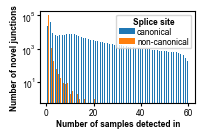

[Excluding testis] ALL novel junctions: 297,419 | 1 sample 43.2% | >=2 56.8% | median 4 | max 58 of 58
[Excluding testis]       canonical: 190,404 distinct coords from 3,835,588 rows (20.14 rows/coord) | 1 sample 11.9% | >=2 88.1% | median 11 | max 58 of 58
[Excluding testis]   non_canonical: 107,015 distinct coords from 109,029 rows (1.02 rows/coord) | 1 sample 98.8% | >=2 1.2% | median 1 | max 20 of 58


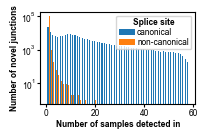

In [7]:
# Per novel junction: number of distinct samples (tube_id) it is detected in.
# SPLIT BY CANONICAL STATUS -- this is what the pooled statistic was hiding. Non-canonical
# novel junctions are ~33% of the DISTINCT novel coordinates but only ~1.02 observations
# each across the whole atlas (i.e. each is seen once and never again), so they are almost
# all single-sample and they dominate the pooled "sample-private" fraction. Canonical
# (GT-AG etc.) novel junctions behave like the isoforms that carry them (~89% in >= 2
# samples). Canonical-only is also the target definition used by the short-read junction
# validation in 03_06, so the two analyses stay consistent.
# Note the coordinate key is EXACT; `isoseq collapse` merges junctions within
# --max-fuzzy-junction (default 5 bp) into one global PB ID while each tube's recollapsed
# GFF keeps its OWN original coordinates, so a few percent of canonical junctions fragment
# across tubes purely from that drift (merging coords within +/-5 bp moves single-sample
# from ~10.8% to ~7.4%).
# Testis contributes by far the most novel junctions, so the distribution is also shown
# with testis samples excluded. Each subset is its OWN figure (was a 1x2 grid) so the
# panels can be placed separately.
JKEY = ["chrom", "strand", "genomic_start_coord", "genomic_end_coord"]
_nov_all = junctions[junctions["junction_category"] == "novel"]
_is_testis = _nov_all["tissue"].astype(str).str.contains("testis", case=False, na=False)
subsets = [("All samples", "all_samples", _nov_all),
           ("Excluding testis", "excluding_testis", _nov_all[~_is_testis])]
# C0/C1 = the active matplotlib prop_cycle (tab10), i.e. the same blue/orange pandas
# assigns to canonical/non_canonical in the section-3 crosstab bar and to known/novel
# in section 4, so the canonical split is colored consistently across the notebook.
CANON_SPLIT = [("canonical", "C0"), ("non_canonical", "C1")]

breadth_junc = {}
for title, slug, dat in subsets:
    N = dat["tube_id"].nunique()
    # pooled (previous behaviour), kept so the old number stays visible/comparable
    nsamp_all = dat.groupby(JKEY, observed=True)["tube_id"].nunique()
    print(f"[{title}] ALL novel junctions: {len(nsamp_all):,} | "
          f"1 sample {(nsamp_all == 1).mean():.1%} | >=2 {(nsamp_all >= 2).mean():.1%} | "
          f"median {nsamp_all.median():.0f} | max {nsamp_all.max()} of {N}")

    fig, ax = plt.subplots(figsize=(2.0, 1.2))
    for _i, (cstat, color) in enumerate(CANON_SPLIT):
        sub = dat[dat["canonical"] == cstat]
        if not len(sub):
            continue
        nsamp = sub.groupby(JKEY, observed=True)["tube_id"].nunique()
        breadth_junc[(title, cstat)] = nsamp
        dist = nsamp.value_counts().sort_index()
        # dodged bars (not stacked): a log y-axis makes stacked heights unreadable
        ax.bar(dist.index + (_i - 0.5) * 0.42, dist.values, width=0.42,
               color=color, linewidth=0, label=cstat.replace("_", "-"))
        print(f"[{title}]   {cstat:>13s}: {len(nsamp):,} distinct coords from {len(sub):,} rows "
              f"({len(sub)/len(nsamp):.2f} rows/coord) | 1 sample {(nsamp == 1).mean():.1%} | "
              f">=2 {(nsamp >= 2).mean():.1%} | median {nsamp.median():.0f} | max {nsamp.max()} of {N}")
    ax.set_yscale("log")   # heavy right-skew, and the two classes differ by orders of magnitude
    ax.set_xlabel("Number of samples detected in")
    ax.set_ylabel("Number of novel junctions")
    _ncan = len(breadth_junc.get((title, "canonical"), []))
    # ax.set_title(f"{title}\n({_ncan:,} canonical novel junctions, {N} samples)", pad=PANEL_TITLE_PAD)
    ax.legend(title="Splice site", loc="upper right")
    plt.savefig(figpath(f"03_02_novel_junction_sample_breadth_{slug}.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()

#3. Splice site motifs

In [8]:
import os
os.makedirs("figures", exist_ok=True)

# COUNTING CONVENTION: distinct junctions, NOT junction rows.
# `junctions` holds one row per (isoform, junction, sample), so a junction used by 40 isoforms
# across 12 tissues contributes 480 rows. Any count of *things* -- how many junctions carry a
# motif, how many are novel, how many are non-canonical -- has to be taken over distinct
# (chrom, genomic_start_coord, genomic_end_coord), or it measures isoform reuse and tissue
# recurrence instead of the size of the catalogue.
#
# The difference is not cosmetic. Verified atlas-wide over the pbids-object isoforms
# (csvs/junction_counts_pbids_object.csv): 74,676,658 rows collapse to 586,304 distinct
# junctions, and the novel share moves 5.7% (rows) -> 57.9% (distinct), because known canonical
# junctions recur ~286x per coordinate while novel canonical ones recur ~18x. Occurrence-weighted
# counts mostly report that annotated junctions sit in highly expressed multi-isoform genes.
#
# Rates about how OFTEN splicing occurs (the per-tissue novel fraction further down) are
# legitimately observation-level and stay row-based; they are labelled as such.
JXKEY = ["chrom", "genomic_start_coord", "genomic_end_coord"]
jx = junctions.drop_duplicates(JXKEY)
print(f"junction rows {len(junctions):,} -> distinct junctions {len(jx):,} "
      f"({len(junctions)/len(jx):.1f} observations per distinct junction)")

motif_counts = None
ct = None
if "splice_site" in jx.columns:
    motif_counts = jx["splice_site"].value_counts().head(10)
    print("\nSplice site motif distribution, DISTINCT junctions (top 10):")
    print(motif_counts)

    ct = pd.crosstab(jx["junction_category"], jx["canonical"])
    print("\nJunction category x canonical status (DISTINCT junctions):")
    print(ct)
else:
    print("splice_site column not found")

jcat_counts = jx["junction_category"].value_counts()
canon_counts = jx["canonical"].value_counts()

# Both conventions side by side, so the contrast is on the record rather than implicit.
_row_ct = pd.crosstab(junctions["junction_category"], junctions["canonical"])
print("\nnovel share under each convention:")
for _lab, _t in [("rows", _row_ct), ("distinct", ct)]:
    if _t is not None:
        _nov = _t.loc["novel"].sum() if "novel" in _t.index else 0
        print(f"  {_lab:9s} total {_t.values.sum():>12,} | novel {_nov:>10,} ({_nov/_t.values.sum():.1%})")

# [verify] the draft's "Of 474,899 canonical junctions, 228,226 (48.1%) were unannotated".
# Distinct coordinates, canonical motif only, known + novel.
if ct is not None and "canonical" in ct.columns:
    _tc = int(ct["canonical"].sum())
    _nc = int(ct.loc["novel", "canonical"]) if "novel" in ct.index else 0
    print(f"\n[verify] distinct CANONICAL junctions {_tc:,} total | "
          f"novel {_nc:,} ({100 * _nc / max(_tc, 1):.1f}%) | known {_tc - _nc:,}")


junction rows 74,676,658 -> distinct junctions 586,304 (127.4 observations per distinct junction)

Splice site motif distribution, DISTINCT junctions (top 10):
splice_site
GTAG    448126
GCAG     24553
AATT      6082
AAAT      5976
AAGG      5607
AACT      4499
AAAC      3484
AACA      3361
AAGT      3130
AATC      2983
Name: count, dtype: int64

Junction category x canonical status (DISTINCT junctions):
canonical          canonical  non_canonical
junction_category                          
known                 246673            117
novel                 228226         111288

novel share under each convention:
  rows      total   74,676,658 | novel  4,230,752 (5.7%)
  distinct  total      586,304 | novel    339,514 (57.9%)

[verify] distinct CANONICAL junctions 474,899 total | novel 228,226 (48.1%) | known 246,673


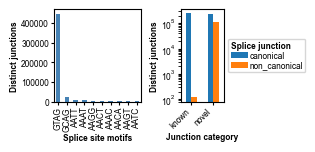

In [9]:
if motif_counts is not None:
    fig, axes = plt.subplots(1, 2, figsize=(2.2, 1.2), gridspec_kw={'width_ratios': [1, 0.5]})

    motif_counts.plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_ylabel("Distinct junctions")
    axes[0].set_xlabel("Splice site motifs")
    plt.sca(axes[0])
    plt.xticks(rotation=90, ha="center")

    ct.plot(kind="bar", ax=axes[1])
    axes[1].set_xlabel("Junction category")
    axes[1].set_ylabel("Distinct junctions")
    axes[1].set_yscale('log')
    axes[1].legend(loc="center left", bbox_to_anchor=(1.00, 0.5), title="Splice junction",
                  alignment = "left")
    plt.sca(axes[1])
    plt.xticks(rotation=45, ha="right")
    plt.subplots_adjust(wspace = 0.60)
    plt.savefig(figpath("03_02_splice_site_motifs.pdf"))   # PAPER: sequence features / splice signals


#4. Per-tissue novel junction usage

In [10]:
tissue_junction_stats = junctions.groupby("tissue").apply(
    lambda x: pd.Series({
        "total": len(x),
        "novel": (x["junction_category"] == "novel").sum(),
        "known": (x["junction_category"] == "known").sum(),
        "novel_frac": (x["junction_category"] == "novel").mean(),
        "non_canonical": (x["canonical"] == "non_canonical").sum() if "non_canonical" in x["canonical"].values else 0,
    })
).sort_values("novel_frac", ascending=False)
print(tissue_junction_stats)

                     total     novel      known  novel_frac  non_canonical
tissue                                                                    
Testis           3254297.0  286135.0  2968162.0    0.087925         4564.0
Lymph_Node       2662631.0  166702.0  2495929.0    0.062608         3791.0
Uterus           3183263.0  194353.0  2988910.0    0.061055         4223.0
Ear              3277455.0  199091.0  3078364.0    0.060746         4992.0
Lung             3255149.0  193386.0  3061763.0    0.059409         3605.0
Spleen           2051688.0  121262.0  1930426.0    0.059104         4027.0
Stomach          3286729.0  191342.0  3095387.0    0.058217         4256.0
Fat              3280012.0  188713.0  3091299.0    0.057534         4352.0
Bladder          3332303.0  190915.0  3141388.0    0.057292         3754.0
Blood            5412320.0  302193.0  5110127.0    0.055834        10644.0
Small_Intestine  2530904.0  140748.0  2390156.0    0.055612         3748.0
Pancreas         3247713.

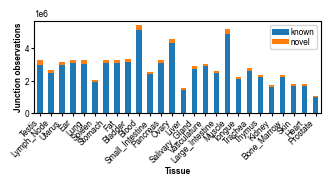

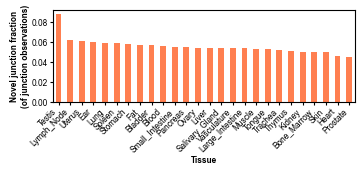

In [11]:
# UNIT: both panels here are deliberately OCCURRENCE-WEIGHTED. They answer how often a
# junction observation is novel in each tissue, which is a rate about events rather than a
# count of distinct junctions -- the one place in this section where row-based counting is
# the right choice. Supp 4A/4B count distinct junctions instead; the y-labels state which is
# which so the two can never be read as the same quantity.
fig, ax = plt.subplots(1, 1, figsize=(3.7, 1.2))

tissue_junction_stats[["known", "novel"]].plot(kind="bar", stacked=True, ax=ax)
ax.set_xlabel("Tissue")
ax.set_ylabel("Junction observations")
plt.sca(ax)
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_02_novel_junctions_per_tissue.pdf"))   # PAPER: known vs novel junctions across tissues
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(3.9, 1.2))
tissue_junction_stats["novel_frac"].plot(kind="bar", ax=ax, color="coral")
ax.set_xlabel("Tissue")
ax.set_ylabel("Novel junction fraction\n(of junction observations)")
plt.sca(ax)
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_02_novel_junctions_fractions_per_tissue.pdf"))   # PAPER: known vs novel junctions across tissues
plt.show()


#5. Exon skipping detection

In [12]:
# Load combined SQANTI3 classification for isoform-gene mapping and subcategories
classification = pd.read_csv("./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                              usecols=["isoform", "associated_gene", "structural_category",
                                       "subcategory", "exons", "tissue_source"])
classification = classification.rename(columns={"tissue_source": "tissue"})
classification["tissue"] = classification["tissue"].map(tube_to_tissue).fillna(classification["tissue"])

# Section 5: restrict the classification to molecules present in the preprocessed dataset
# (robust_isoforms built near the top from the preprocessed pbids object).
_nc0 = len(classification)
classification = classification[classification["isoform"].astype(str).isin(robust_isoforms)].copy()
print(f"Restricted classification to preprocessed-molecule isoforms: {_nc0:,} -> {len(classification):,} ({len(classification)/_nc0:.1%} kept)")
print(f"Classification records: {len(classification)}")
print(f"Tissues: {sorted(classification['tissue'].unique())}")

# Subcategory analysis for exon skipping
print("\nSubcategory distribution:")
# Subcategory can contain multiple values separated by underscore or comma
subcats = classification["subcategory"].dropna()#.str.split("_").explode()
print(subcats.value_counts().head(20))

Restricted classification to preprocessed-molecule isoforms: 11,529,975 -> 854,410 (7.4% kept)
Classification records: 854410
Tissues: ['Bladder', 'Blood', 'Bone_Marrow', 'Ear', 'Fat', 'Heart', 'Kidney', 'Large_Intestine', 'Liver', 'Lung', 'Lymph_Node', 'Muscle', 'Ovary', 'Pancreas', 'Prostate', 'Salivary_Gland', 'Skin', 'Small_Intestine', 'Spleen', 'Stomach', 'Testis', 'Thymus', 'Tongue', 'Trachea', 'Uterus', 'Vasculature']

Subcategory distribution:
subcategory
at_least_one_novel_splicesite       183815
3prime_fragment                     142917
internal_fragment                   142268
5prime_fragment                     121962
combination_of_known_splicesites     54396
intron_retention                     49587
combination_of_known_junctions       46715
alternative_3end                     27374
alternative_3end5end                 22375
mono-exon                            20292
reference_match                      16983
alternative_5end                     15696
multi-exon      

Tissues: ['Bladder', 'Blood', 'Bone_Marrow', 'Ear', 'Fat', 'Heart', 'Kidney', 'Large_Intestine', 'Liver', 'Lung', 'Lymph_Node', 'Muscle', 'Ovary', 'Pancreas', 'Prostate', 'Salivary_Gland', 'Skin', 'Small_Intestine', 'Spleen', 'Stomach', 'Testis', 'Thymus', 'Tongue', 'Trachea', 'Uterus', 'Vasculature']

Subcategory distribution:


subcategory
at             7486558
least          7486558
one            7486558
novel          7486558
splicesite     7486558
fragment       4246676
multi-exon     2876373
known          1766232
of             1766232
combination    1766232
internal       1747214
3prime         1380436
retention      1328446
intron         1328446
splicesites    1168223
5prime         1119026
mono-exon       955867
alternative     857535
junctions       598009
3end5end        452600
Name: count, dtype: int64


In [13]:
# ===== 5. Candidate exon-skipping (cassette) events -- COORDINATE-BASED =====
# REWRITTEN (the previous version produced the 22,489 figure quoted in the draft).
#
# What the old cell did: it collected each isoform's junction start/end lists, NEVER READ THEM,
# and flagged any (gene, tissue) whose isoforms merely differed in EXON COUNT
# (n_isoforms >= 2 and max(exons) - min(exons) >= 1). That criterion is satisfied by every
# 5'/3'/internal ISM fragment (407,147 isoforms, ~48% of the robust set), by alternative first/
# last exons, and by intron retention -- so it counted multi-isoform genes, not skipping, and
# double-counted the intron-retention isoforms reported in section 6.
# It also merged the classification on ["isoform", "tissue"], but the combined classification
# holds ONE row per isoform with a single tissue_source, so most (isoform, tissue) pairs got
# NaN gene/exons and were silently dropped by the groupby (pandas dropna=True).
#
# What an exon-skipping event actually is: an "exclusion" junction (a, d) coexisting, in the same
# gene and sample, with "inclusion" junctions (a, b) and (c, d) where a < b < c < d. The region
# b..c is spliced out by (a, d) but retained via the inclusion pair.
#
# Vectorized test -- for an exclusion junction (a, d), inclusion partners exist iff
#     min{ ends of junctions sharing donor a }  <  max{ starts of junctions sharing acceptor d }
# b is drawn from ends-at-a and c from starts-at-d, and ANY b < c pair suffices, so the extreme
# candidates decide it. A junction is never its own partner: if (a, d) is alone at donor a then
# the min is d, which cannot fall below max(starts at d) < d. Two groupbys, one comparison --
# no triple self-join. Run on bigmem (junctions is ~74.7M rows).
import gc

# --- 0. gene per isoform. Fusion isoforms are EXCLUDED: their associated_gene spans two loci,
#        which would manufacture "skipping" across the fusion breakpoint. ---
_cls = classification[classification["structural_category"] != "fusion"]
iso2gene = _cls.set_index("isoform")["associated_gene"]
_gcat = pd.Categorical(junctions["isoform"].map(iso2gene))
_tcat = pd.Categorical(junctions["tissue"].astype(str))
gene_names = _gcat.categories
tissue_names = _tcat.categories          # keep: the cassette cell below maps codes back

jd = pd.DataFrame({
    "gene":   _gcat.codes.astype(np.int32),          # -1 where unmapped (fusion / absent)
    "tissue": _tcat.codes.astype(np.int16),
    "start":  pd.to_numeric(junctions["genomic_start_coord"], errors="coerce").to_numpy(),
    "end":    pd.to_numeric(junctions["genomic_end_coord"], errors="coerce").to_numpy(),
    "novel":  (junctions["junction_category"].to_numpy() == "novel"),
})
del _gcat, _tcat
gc.collect()
jd = jd[jd["gene"] >= 0]
jd = jd.drop_duplicates(["gene", "tissue", "start", "end"])
print(f"distinct (gene, sample-tissue, junction) records: {len(jd):,} "
      f"over {jd['gene'].nunique():,} genes")

# --- 1. donor / acceptor extremes, then the skipping test ---
gmin = (jd.groupby(["gene", "tissue", "start"], observed=True)["end"].min()
          .rename("min_end_at_donor").reset_index())
gmax = (jd.groupby(["gene", "tissue", "end"], observed=True)["start"].max()
          .rename("max_start_at_acceptor").reset_index())
ev = jd.merge(gmin, on=["gene", "tissue", "start"], how="left")
ev = ev.merge(gmax, on=["gene", "tissue", "end"], how="left")
del gmin, gmax
gc.collect()

skip = ev[ev["min_end_at_donor"] < ev["max_start_at_acceptor"]].copy()
skip["skipped_start"] = skip["min_end_at_donor"]
skip["skipped_end"]   = skip["max_start_at_acceptor"]
skip["skipped_len"]   = skip["skipped_end"] - skip["skipped_start"]

# --- 2. results ---
es_genes = np.sort(gene_names[np.unique(skip["gene"].to_numpy())].to_numpy())
n_gt = skip.groupby(["gene", "tissue"], observed=True).ngroups
n_regions = len(skip.drop_duplicates(["gene", "skipped_start", "skipped_end"]))
print("\n--- coordinate-based exon skipping ---")
print(f"  genes with >=1 candidate skipping event : {len(es_genes):,}")
print(f"  gene-tissue combinations                : {n_gt:,}")
print(f"  exclusion junctions implying a skip     : {len(skip):,}")
print(f"  distinct skipped regions (gene-unique)  : {n_regions:,}")
print(f"  exclusion junction is NOVEL             : {skip['novel'].mean():.1%}")
print(f"  skipped-region length: median {skip['skipped_len'].median():,.0f} nt "
      f"(IQR {skip['skipped_len'].quantile(.25):,.0f}-{skip['skipped_len'].quantile(.75):,.0f})")
print("  NOTE: one exclusion junction may skip more than one exon. The next cell separates the\n"
      "        strict single-cassette case (no junction contained in the skipped region).")

# --- 3. the OLD metric, recomputed with the merge bug FIXED, to separate the two defects ---
# merging on "isoform" ALONE is the correction: associated_gene and exons are isoform
# properties and do not vary by tissue.
iso_meta = classification.set_index("isoform")[["associated_gene", "exons"]]
ij = pd.DataFrame({"isoform": junctions["isoform"].to_numpy(),
                   "tissue": junctions["tissue"].astype(str).to_numpy()}).drop_duplicates()
ij = ij.join(iso_meta, on="isoform")
ij["exons"] = pd.to_numeric(ij["exons"], errors="coerce")
gv = ij.groupby(["associated_gene", "tissue"], observed=True).agg(
        n_isoforms=("isoform", "nunique"), exon_min=("exons", "min"), exon_max=("exons", "max"))
old_fixed = gv[(gv["n_isoforms"] >= 2) & ((gv["exon_max"] - gv["exon_min"]) >= 1)]
old_genes = old_fixed.index.get_level_values("associated_gene").unique()
print("\n--- old 'exon count differs' metric, with the (isoform, tissue) merge bug fixed ---")
print(f"  genes: {len(old_genes):,} (published value from the buggy merge: 22,489) "
      f"| gene-tissue combinations: {len(old_fixed):,} (was 70,414)")
print(f"  of those genes, {len(set(old_genes) & set(es_genes)):,} also carry a real "
      f"coordinate-supported skipping event")
del ev, ij, gv
gc.collect()

distinct (gene, sample-tissue, junction) records: 6,884,530 over 34,735 genes

--- coordinate-based exon skipping ---
  genes with >=1 candidate skipping event : 17,607
  gene-tissue combinations                : 283,796
  exclusion junctions implying a skip     : 1,005,188
  distinct skipped regions (gene-unique)  : 122,936
  exclusion junction is NOVEL             : 48.4%
  skipped-region length: median 332 nt (IQR 115-4,148)
  NOTE: one exclusion junction may skip more than one exon. The next cell separates the
        strict single-cassette case (no junction contained in the skipped region).

--- old 'exon count differs' metric, with the (isoform, tissue) merge bug fixed ---
  genes: 24,448 (published value from the buggy merge: 22,489) | gene-tissue combinations: 424,280 (was 70,414)
  of those genes, 17,544 also carry a real coordinate-supported skipping event


0

--- strict single-exon cassettes ---
  candidate skipped regions            : 122,936
  of which single-exon cassettes       : 65,284 (53.1%)
  genes with >=1 single-exon cassette  : 17,272
  exclusion junction NOVEL             : 41.2%
  cassette exon length: median 141 nt (IQR 93-391)
  SANITY CHECK: real cassette exons are typically ~50-250 nt. A median far outside that
                range means the region definition, not the biology, is driving the result.

saved ./../csvs/03_02_cassette_exon_events.csv (65,284 rows)


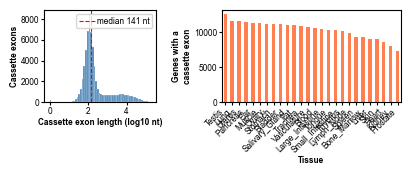

In [14]:
# ===== 5b. Strict single-exon cassettes =====
# A skipped region b..c is a SINGLE cassette exon only if no intron lies wholly inside it; if one
# does, the exclusion junction removed two or more exons. Containment is judged against the
# ATLAS-POOLED junction set for the gene (a region is a single exon only if NO sample shows a
# junction inside it), which is the stricter choice.
#
# Test: sort the gene's junctions by donor and take the suffix-minimum of their acceptors. A
# junction with start >= b and end <= c exists iff suffix_min_end[searchsorted(starts, b)] <= c.
# The flanking inclusion junctions can never trigger it -- (a, b) starts before b, and (c, d)
# ends after c -- so no self-exclusion is needed.

gj = (jd.drop_duplicates(["gene", "start", "end"])[["gene", "start", "end"]]
        .sort_values(["gene", "start"]))
reg = skip.drop_duplicates(["gene", "skipped_start", "skipped_end"])[
        ["gene", "skipped_start", "skipped_end", "skipped_len", "novel"]].copy()

gj_by_gene = dict(list(gj.groupby("gene", sort=False)))
parts = []
for g, sub in reg.groupby("gene", sort=False):
    jj = gj_by_gene[g]
    S = jj["start"].to_numpy()
    sufmin = np.minimum.accumulate(jj["end"].to_numpy()[::-1])[::-1]
    idx = np.searchsorted(S, sub["skipped_start"].to_numpy(), side="left")
    inside = np.zeros(len(sub), dtype=bool)
    ok = idx < len(S)
    inside[ok] = sufmin[idx[ok]] <= sub["skipped_end"].to_numpy()[ok]
    sub = sub.copy(); sub["single_exon"] = ~inside
    parts.append(sub)
reg = pd.concat(parts, ignore_index=True)
del gj_by_gene, parts
gc.collect()

cas = reg[reg["single_exon"]]
cas_genes = np.sort(gene_names[np.unique(cas["gene"].to_numpy())].to_numpy())
print("--- strict single-exon cassettes ---")
print(f"  candidate skipped regions            : {len(reg):,}")
print(f"  of which single-exon cassettes       : {len(cas):,} ({len(cas)/len(reg):.1%})")
print(f"  genes with >=1 single-exon cassette  : {len(cas_genes):,}")
print(f"  exclusion junction NOVEL             : {cas['novel'].mean():.1%}")
print(f"  cassette exon length: median {cas['skipped_len'].median():,.0f} nt "
      f"(IQR {cas['skipped_len'].quantile(.25):,.0f}-{cas['skipped_len'].quantile(.75):,.0f})")
print("  SANITY CHECK: real cassette exons are typically ~50-250 nt. A median far outside that\n"
      "                range means the region definition, not the biology, is driving the result.")

# --- per-tissue: genes carrying a single-exon cassette (merge, not a row-wise lookup) ---
sk = skip[["gene", "tissue", "skipped_start", "skipped_end"]].merge(
        cas[["gene", "skipped_start", "skipped_end"]].assign(is_cassette=True),
        on=["gene", "skipped_start", "skipped_end"], how="left")
sk["is_cassette"] = sk["is_cassette"].fillna(False).astype(bool)
per_tissue_cas = (sk[sk["is_cassette"]].groupby("tissue", observed=True)["gene"].nunique()
                    .rename(lambda i: tissue_names[i]).sort_values(ascending=False))

# --- save the event table ---
out = cas.copy()
out["gene"] = gene_names[out["gene"].to_numpy()]
out = out.rename(columns={"novel": "exclusion_junction_novel"})
out[["gene", "skipped_start", "skipped_end", "skipped_len",
     "exclusion_junction_novel"]].to_csv("./../csvs/03_02_cassette_exon_events.csv", index=False)
print(f"\nsaved ./../csvs/03_02_cassette_exon_events.csv ({len(out):,} rows)")

# --- figure: cassette length distribution + genes per tissue ---
fig, axes = plt.subplots(1, 2, figsize=(4.6, 1.2), gridspec_kw={"width_ratios": [1, 1.6]})
axes[0].hist(np.log10(cas["skipped_len"].clip(lower=1)), bins=60,
             color="steelblue", edgecolor="white", linewidth=0.2)
axes[0].axvline(np.log10(cas["skipped_len"].median()), color="red", ls="--", lw=0.8,
                label=f"median {cas['skipped_len'].median():,.0f} nt")
axes[0].set_xlabel("Cassette exon length (log10 nt)")
axes[0].set_ylabel("Cassette exons")
axes[0].legend()
per_tissue_cas.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_xlabel("Tissue")
axes[1].set_ylabel("Genes with a\ncassette exon")
plt.sca(axes[1]); plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(wspace=0.45)
plt.savefig(figpath("03_02_cassette_exons.pdf"), bbox_inches="tight", dpi=300)
plt.show()

#6. Intron retention

In [15]:
# Identify isoforms with intron retention from subcategory
ir_mask = classification["subcategory"].str.contains("intron_retention", case=False, na=False)
ir_isoforms = classification[ir_mask]
print(f"Isoforms with intron retention: {len(ir_isoforms)}")
print(f"Unique isoforms: {ir_isoforms['isoform'].nunique()}")
print(f"Unique genes: {ir_isoforms['associated_gene'].nunique()}")

# Per tissue
ir_per_tissue = ir_isoforms.groupby("tissue")["isoform"].nunique()


Isoforms with intron retention: 49587
Unique isoforms: 49587
Unique genes: 10316


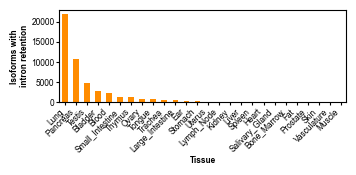

In [16]:
fig, ax = plt.subplots(figsize=(3.7, 1.2))
ir_per_tissue.sort_values(ascending=False).plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Isoforms with\nintron retention")
ax.set_xlabel("Tissue")
# ax.set_title("Intron retention events per tissue")
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("03_02_intron_retention_per_tissue.pdf"))   # PAPER: intron retention
plt.show()


#7. Alternative 5'/3' splice sites

In [17]:
# Novel splice SITES -- counted as distinct sites, strand-aware.
#
# Two corrections over the previous version of this cell, which did
#     len(junctions[junctions["start_site_category"] == "novel"])
# and reported the result as a count of 5' splice sites:
#
# 1. DISTINCT, not rows. That expression counts junction observations, so it inherits isoform
#    reuse and tissue recurrence. It also produced a figure (~1.95M) that is impossible as a
#    site count: a junction has one donor and one acceptor, so distinct novel donors cannot
#    exceed the 339,514 distinct novel junctions in this atlas.
#
# 2. STRAND. SQANTI reports genomic_start_coord / genomic_end_coord, and the matching
#    start_site_category / end_site_category, in GENOMIC order regardless of strand. The 5'
#    splice site (donor) is therefore the genomic START on + strand but the genomic END on -
#    strand. Reading start_site_category as "the 5' site" mislabels every minus-strand junction
#    -- roughly half the data -- and swaps donors with acceptors for those.
ss_counts = pd.crosstab(junctions["start_site_category"], junctions["end_site_category"])
print("Start x End site category crosstab (junction rows, genomic order):")
print(ss_counts)

_minus = (junctions["strand"].astype(str) == "-").to_numpy()
_gs    = junctions["genomic_start_coord"].to_numpy()
_ge    = junctions["genomic_end_coord"].to_numpy()
_sc    = junctions["start_site_category"].astype(str).to_numpy()
_ec    = junctions["end_site_category"].astype(str).to_numpy()
_ch    = junctions["chrom"].astype(str).to_numpy()

donor_pos, donor_cat = np.where(_minus, _ge, _gs), np.where(_minus, _ec, _sc)
accep_pos, accep_cat = np.where(_minus, _gs, _ge), np.where(_minus, _sc, _ec)

def _distinct_sites(mask, pos):
    if not mask.any():
        return 0
    return len(pd.DataFrame({"c": _ch[mask], "p": pos[mask]}).drop_duplicates())

m5, m3 = (donor_cat == "novel"), (accep_cat == "novel")
n5, n3 = _distinct_sites(m5, donor_pos), _distinct_sites(m3, accep_pos)
print(f"\nDistinct novel 5' (donor) splice sites   : {n5:,}")
print(f"Distinct novel 3' (acceptor) splice sites: {n3:,}")
print(f"  junction ROWS with a novel donor {int(m5.sum()):,} / novel acceptor {int(m3.sum()):,}"
      f"  <- the previous, occurrence-weighted and strand-unaware numbers")

# Distance from the annotated site, one value per DISTINCT site and in TRANSCRIPT orientation.
# diff_to_Ref_* is (observed - reference) in genomic coordinates, so on the minus strand the
# sign is inverted relative to transcript direction; negate it there so "upstream" means the
# same thing on both strands. Deduplicating matters here too: without it the histogram is
# dominated by whichever novel sites happen to recur most.
_d5 = pd.to_numeric(pd.Series(np.where(_minus, junctions["diff_to_Ref_end_site"],
                                       junctions["diff_to_Ref_start_site"])), errors="coerce")
_d3 = pd.to_numeric(pd.Series(np.where(_minus, junctions["diff_to_Ref_start_site"],
                                       junctions["diff_to_Ref_end_site"])), errors="coerce")
_d5 = np.where(_minus, -_d5, _d5); _d3 = np.where(_minus, -_d3, _d3)

def _site_offsets(mask, pos, diff):
    d = pd.DataFrame({"c": _ch[mask], "p": pos[mask], "d": diff[mask]}).drop_duplicates(["c", "p"])
    d = d["d"].dropna()
    return d[(d != 0) & (d.abs() <= 100)]

diffs_start = _site_offsets(m5, donor_pos, _d5) if "diff_to_Ref_start_site" in junctions.columns else None
diffs_end   = _site_offsets(m3, accep_pos, _d3) if "diff_to_Ref_end_site"   in junctions.columns else None
if diffs_start is not None:
    print(f"\noffsets plotted: {len(diffs_start):,} distinct novel donors, "
          f"{len(diffs_end):,} distinct novel acceptors (|offset| <= 100 bp, non-zero)")
    print(f"  median |offset| donor {diffs_start.abs().median():.0f} bp, "
          f"acceptor {diffs_end.abs().median():.0f} bp")


Start x End site category crosstab (junction rows, genomic order):
end_site_category       known    novel
start_site_category                   
known                71503111  1218963
novel                 1229259   725325

Distinct novel 5' (donor) splice sites   : 172,113
Distinct novel 3' (acceptor) splice sites: 198,687
  junction ROWS with a novel donor 1,829,357 / novel acceptor 2,069,515  <- the previous, occurrence-weighted and strand-unaware numbers

offsets plotted: 31,780 distinct novel donors, 35,491 distinct novel acceptors (|offset| <= 100 bp, non-zero)
  median |offset| donor 26 bp, acceptor 21 bp


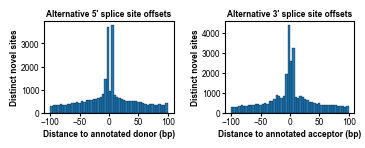

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(4, 1.2))

if diffs_start is not None:
    axes[0].hist(diffs_start, bins=50, edgecolor="black", linewidth=0.2)
    axes[0].set_xlabel("Distance to annotated donor (bp)")
    axes[0].set_ylabel("Distinct novel sites")
    axes[0].set_title("Alternative 5' splice site offsets")

if diffs_end is not None:
    axes[1].hist(diffs_end, bins=50, edgecolor="black", linewidth=0.2)
    axes[1].set_xlabel("Distance to annotated acceptor (bp)")
    axes[1].set_ylabel("Distinct novel sites")
    axes[1].set_title("Alternative 3' splice site offsets")

plt.subplots_adjust(wspace = 0.40)
plt.savefig(figpath("03_02_alt_splice_site_offsets.pdf"))   # PAPER: alternative 5'/3' splice-site usage
plt.show()


#8. Conservation scores for novel vs known splice sites

In [19]:
has_phylop_data = "phyloP_start" in junctions.columns and "phyloP_end" in junctions.columns
has_phylop = None
if has_phylop_data:
    junctions["phyloP_start_num"] = pd.to_numeric(junctions["phyloP_start"], errors="coerce")
    junctions["phyloP_end_num"] = pd.to_numeric(junctions["phyloP_end"], errors="coerce")
    junctions["mean_phyloP"] = (junctions["phyloP_start_num"] + junctions["phyloP_end_num"]) / 2

    has_phylop = junctions["mean_phyloP"].notna()
    print(f"Junctions with phyloP scores: {has_phylop.sum()} / {len(junctions)}")
    if has_phylop.sum() == 0:
        print("No phyloP scores available (all NA)")
else:
    print("phyloP columns not found in junction data")

Junctions with phyloP scores: 0 / 74676658
No phyloP scores available (all NA)


In [20]:
if has_phylop_data and has_phylop is not None and has_phylop.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    for cat in ["known", "novel"]:
        mask = (junctions["junction_category"] == cat) & has_phylop
        if mask.sum() > 0:
            ax.hist(junctions.loc[mask, "mean_phyloP"], bins=50, alpha=0.6,
                    label=f"{cat} (n={mask.sum()})", density=True)
    ax.set_xlabel("Mean phyloP score")
    ax.set_ylabel("Density")
    ax.set_title("Conservation of splice sites: known vs novel")
    ax.legend()
    plt.savefig(figpath("03_02_splice_site_conservation.pdf"))   # PAPER: splice-site conservation (known vs novel)
    plt.show()

#9. Splicing events by structural category (NIC/NNC subcategories)

In [21]:
# Subcategory analysis for NIC and NNC
nic_ncc = classification[classification["structural_category"].isin(
    ["novel_in_catalog", "novel_not_in_catalog"]
)]

# Parse multi-value subcategories
subcat_expanded = nic_ncc["subcategory"].dropna().str.split("_").explode()
subcat_by_cat = nic_ncc[["structural_category", "subcategory"]].dropna()

print("Subcategories of novel isoforms:")
for cat in ["novel_in_catalog", "novel_not_in_catalog"]:
    cat_subcats = subcat_by_cat[subcat_by_cat["structural_category"] == cat]["subcategory"].value_counts()
    print(f"\n{cat}:")
    print(cat_subcats.head(10))

# Overall subcategory by structural category — PAPER: SQANTI3-derived AS-event catalog (isoform-level)
ct = pd.crosstab(classification["structural_category"], classification["subcategory"], dropna = False)
# Plot top subcategories
top_subcats = classification["subcategory"].value_counts().index


Subcategories of novel isoforms:

novel_in_catalog:
subcategory
combination_of_known_splicesites    54396
combination_of_known_junctions      46715
intron_retention                    26322
Name: count, dtype: int64

novel_not_in_catalog:
subcategory
at_least_one_novel_splicesite    183815
intron_retention                  10195
Name: count, dtype: int64


In [22]:
structural_cat_order = ['full-splice_match',
         'incomplete-splice_match',
         'novel_in_catalog',
         'novel_not_in_catalog',
         'fusion',
            'genic',
            'intergenic',
            'moreJunctions',
            'antisense']
structural_cat_order.reverse()
ct = ct.loc[structural_cat_order]

In [23]:
ct

subcategory,3prime_fragment,5prime_fragment,alternative_3end,alternative_3end5end,alternative_5end,at_least_one_novel_splicesite,combination_of_known_junctions,combination_of_known_splicesites,internal_fragment,intron_retention,mono-exon,multi-exon,no_subcategory,reference_match
structural_category,,,,,,,,,,,,,,
antisense,0,0,0,0,0,0,0,0,0,0,239,57,0,0
moreJunctions,0,0,0,0,0,0,0,0,0,4,0,0,75,0
intergenic,0,0,0,0,0,0,0,0,0,0,1562,177,0,0
genic,0,0,0,0,0,0,0,0,0,0,338,3539,0,0
fusion,0,0,0,0,0,0,0,0,0,578,0,6182,0,0
novel_not_in_catalog,0,0,0,0,0,183815,0,0,0,10195,0,0,0,0
novel_in_catalog,0,0,0,0,0,0,46715,54396,0,26322,0,0,0,0
incomplete-splice_match,142917,121962,0,0,0,0,0,0,142268,12488,125,0,0,0
full-splice_match,0,0,27374,22375,15696,0,0,0,0,0,18028,0,0,16983


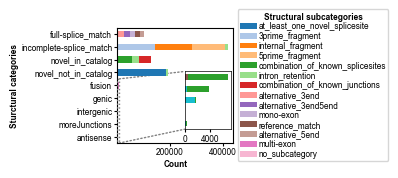

In [24]:
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Rectangle, ConnectionPatch

palette = plt.cm.tab20.colors[:len(top_subcats)]
fig, ax = plt.subplots(figsize=(1.5, 1.5))
ct[top_subcats].plot(kind="barh", ax=ax, stacked=True, color = palette)
ax.set_ylabel("Sturctural categories")
ax.set_xlabel("Count")
# ax.set_xscale('log')
# ax.set_title("Top subcategories by structural category")
ax.legend(title = "Structural subcategories", bbox_to_anchor=(1.00, 0.5), loc=6, fontsize=6)
# plt.xticks(rotation=45, ha="right")

# Zoomed inset, bottom-right: the five smallest structural categories (antisense ...
# fusion, 79-6,760 isoforms) are invisible against ISM/FSM on the full x range. Same
# rows, same stacking order and colours, x-axis rescaled to their own range.
# Rect is [x0, y0, width, height] in axes fractions - nudge it if it crowds the main bars.
zoom_cats = ct.index[:5]                       # ct is ordered bottom-up for the barh
zoom_xmax = ct.loc[zoom_cats].sum(axis=1).max() * 1.08
axin = ax.inset_axes([0.58, 0.12, 0.40, 0.50])
ct.loc[zoom_cats, top_subcats].plot(kind="barh", ax=axin, stacked=True, legend=False, width=0.50)
axin.set_xlim(0, zoom_xmax)
axin.set_xlabel("")
axin.set_ylabel("")
axin.tick_params(axis="y", labelleft=False, left=False)   # rows are identified by the dotted box
# few, short ticks: the inset is ~0.4 in wide, so 4-digit counts would collide
axin.xaxis.set_major_locator(MaxNLocator(nbins=2, integer=True))
# axin.xaxis.set_major_formatter(
#     FuncFormatter(lambda v, _: f"{v/1000:g}k" if v >= 1000 else f"{v:g}")
# )
axin.tick_params(axis="x", length=TICK_LEN, pad=TICK_LABEL_PAD)
for _spine in axin.spines.values():
    _spine.set_linewidth(0.5)
axin.patch.set_alpha(0.85)                     # let the (tiny) main bars show through

# dotted box on the main axes marking exactly the region the inset expands:
# x from 0 to the inset's upper x limit, y spanning the five bottom bars
ax.add_patch(Rectangle((0, -0.5), zoom_xmax, len(zoom_cats), fill=False,
                       edgecolor="grey", linestyle=":", linewidth=1.0, zorder=5))

# two dotted leaders from the box's right corners to the inset's left corners, so the
# inset reads as a magnification of the box. Endpoints follow the box and the inset
# automatically: data coords on ax, axes fractions on axin.
# zorder 0.5 keeps them under the bars (bar patches sit at zorder 1) and above the
# axes background, so the leaders pass behind novel_not_in_catalog rather than over it.
for _box_y, _inset_y in ((4.5, 1.0), (-0.5, 0.0)):
    ax.add_artist(ConnectionPatch(
        xyA=(zoom_xmax, _box_y), coordsA=ax.transData,
        xyB=(0.0, _inset_y), coordsB=axin.transAxes,
        linestyle=":", linewidth=1.0, color="grey", zorder=0.5,
    ))

plt.savefig(figpath("03_02_AS_subcategory_catalog.pdf"))   # PAPER: alternative splicing event catalog
plt.show()

In [25]:
# ===== 10. Single-cell resolution: cell-type-specific novel splicing =====
# Sections 1-9 characterise splicing at the tissue / pooled-catalog level. Here we add the
# single-cell axis this dataset uniquely enables: load the per-cell pbids object, label each
# isoform's splicing novelty (SQANTI structural category), and ask which CELL TYPES drive novel
# splicing (novel_in_catalog + novel_not_in_catalog = new splice junctions), and whether that
# reproduces across DONORS. Heavy load (16.7M isoforms) - run on bigmem.
import scanpy as sc, numpy as np, pandas as pd, gc, os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from add_classification import add_classification
H5AD_DIR = "./../pacbio/h5ads"

adata_sc = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad")
from add_classification import add_classification
add_classification(adata_sc, "./../csvs/all_samples_recollapsed_pigeon_classification.csv",
                   isoform_col="molecule_id", prefix="pigeon_", sep=",")
add_classification(adata_sc, "./../csvs/all_samples_recollapsed_sqanti3_classification.csv",
                   columns=["structural_category", "subcategory", "associated_gene"],
                   isoform_col="molecule_id", prefix="sqanti_", sep=",")
_scat = adata_sc.var["pigeon_structural_category"].astype(str).str.lower()
adata_sc.var["is_novel_splice"] = _scat.isin(["novel_in_catalog", "novel_not_in_catalog"]).values
print(f"novel-splice isoforms: {int(adata_sc.var['is_novel_splice'].sum())} / {adata_sc.n_vars}")
gc.collect()


Columns not found in classification file: {'filter_result'}


novel-splice isoforms: 321443 / 854410


6374

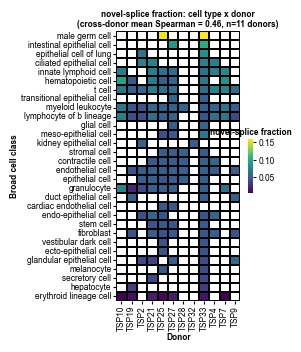

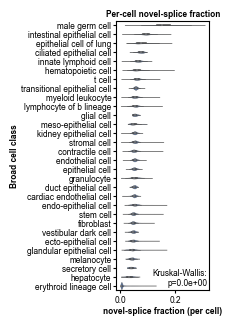

[novel-splice] cross-donor mean pairwise Spearman = 0.461 over 11 donors x 30 broad cell classes


In [26]:
# Single-cell strength: novel-splice usage across cell types + cross-donor reproducibility.
# Two things a bulk long-read study cannot show and that this section makes explicit:
#   (1) the PER-CELL distribution of novel-splice usage across cell types (single-cell resolution), and
#   (2) that the cell-type pattern REPRODUCES across independent donors (multi-donor robustness).
# Efficient: two full-matrix reductions -> per-cell fractions -> cheap groupby (tractable on the
# 16.7M-isoform object). Run on a bigmem node.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr, kruskal
from itertools import combinations

feat_mask = adata_sc.var["is_novel_splice"].values
_ok = bool(feat_mask.sum() > 0)
LABEL = "novel-splice"

if not _ok:
    print("Skipping novel-splice single-cell/cross-donor section - required feature/column not available.")
else:
    _A = adata_sc
    _tot  = np.asarray(_A.X.sum(axis=1)).ravel().astype(float)
    _feat = np.asarray(_A.X[:, feat_mask].sum(axis=1)).ravel().astype(float)
    _frac = np.divide(_feat, _tot, out=np.zeros_like(_feat), where=_tot > 0)

    cell_df = _A.obs[["donor", "broad_cell_class", "cell_ontology_class"]].astype(str).copy()
    cell_df["frac"] = _frac
    cell_df = cell_df[(cell_df["broad_cell_class"] != "unknown") & (_tot > 0)]

    # (A) mean fraction per (broad_cell_class x donor); keep combos with >= 20 cells
    combo = (cell_df.groupby(["broad_cell_class", "donor"], observed=True)["frac"]
                     .agg(["mean", "size"]).reset_index())
    combo = combo[combo["size"] >= 20]
    pivot = combo.pivot(index="broad_cell_class", columns="donor", values="mean")
    pivot = pivot[pivot.notna().sum(axis=1) >= 2]           # cell classes seen in >= 2 donors

    # (B) cross-donor reproducibility = mean pairwise Spearman of the cell-type profiles
    donors = [d for d in pivot.columns if pivot[d].notna().sum() >= 3]
    rhos = []
    for a, b in combinations(donors, 2):
        m = pivot[a].notna() & pivot[b].notna()
        if m.sum() >= 3:
            r, _ = spearmanr(pivot.loc[m, a], pivot.loc[m, b])
            if np.isfinite(r):
                rhos.append(r)
    mean_rho = float(np.mean(rhos)) if rhos else float("nan")
    order = pivot.mean(axis=1).sort_values(ascending=False).index.tolist()

    # preferred plot formatting
    _TICK_LEN  = globals().get("TICK_LEN", 2.0)
    _TICK_PAD  = globals().get("TICK_LABEL_PAD", 1.5)
    _TITLE_PAD = globals().get("PANEL_TITLE_PAD", 3.0)

    # ---- Figure 1: cell-type x donor heatmap (cross-donor reproducibility) ----
    fig1, ax1 = plt.subplots(figsize=(2.0, 3.5))
    sns.heatmap(pivot.loc[order], ax=ax1, cmap="viridis", linewidths=0.05, linecolor="black",
                cbar_kws={"shrink": 0.2, "aspect": 10.0})
    ax1.set_title(f"{LABEL} fraction: cell type x donor\n(cross-donor mean Spearman = {mean_rho:.2f}, n={len(donors)} donors)",
                  fontweight="bold", pad=_TITLE_PAD)
    ax1.set_xlabel("Donor", fontweight="bold")
    ax1.set_ylabel("Broad cell class", fontweight="bold")
    ax1.tick_params(length=_TICK_LEN, pad=_TICK_PAD)
    _cb = ax1.collections[0].colorbar
    _cb.ax.set_title(f"{LABEL} fraction", fontsize=6, fontweight="bold", pad=_TITLE_PAD)  # colorbar title on top
    _cb.ax.tick_params(labelsize=6, length=_TICK_LEN, pad=_TICK_PAD)
    fig1.savefig(figpath("03_02_singlecell_novelsplice_crossdonor_heatmap.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

    # ---- Figure 2: per-cell violin (single-cell distribution) ----
    vdf = cell_df[cell_df["broad_cell_class"].isin(order)].copy()
    if len(vdf) > 60000:
        vdf = vdf.sample(60000, random_state=0)
    fig2, ax2 = plt.subplots(figsize=(1.2, 3.5))
    sns.violinplot(data=vdf, y="broad_cell_class", x="frac", order=order, ax=ax2,
                   inner="box", cut=0, linewidth=0.25, color="#4c72b0")
    ax2.set_title(f"Per-cell {LABEL} fraction", fontweight="bold", pad=_TITLE_PAD)
    ax2.set_xlabel(f"{LABEL} fraction (per cell)", fontweight="bold")
    ax2.set_ylabel("Broad cell class")
    ax2.tick_params(length=_TICK_LEN, pad=_TICK_PAD)

    groups = [g["frac"].values for _, g in vdf.groupby("broad_cell_class", observed=True) if len(g) >= 20]
    if len(groups) >= 2:
        H, pkw = kruskal(*groups)
        ax2.annotate(f"Kruskal-Wallis:\np={pkw:.1e}", xy=(0.98, 0.01),
                     xycoords="axes fraction", ha="right", va="bottom", fontsize=6)

    fig2.savefig(figpath("03_02_singlecell_novelsplice_crossdonor_violin.pdf"), bbox_inches="tight", dpi=300)
    plt.show()
    print(f"[{LABEL}] cross-donor mean pairwise Spearman = {mean_rho:.3f} "
          f"over {len(donors)} donors x {len(order)} broad cell classes")
